In [16]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import uuid
import warnings
import gc
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))

In [17]:
import pandas as pd
import numpy as np
import timesfm
import json

from src.data_loading import load_crypto_data, preprocess_data, split_data
from src.evaluate_forecasts import evaluate_forecast_one_symbol
from models.timesfm_wrapper import TimesFMForecaster
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from config.config import DATA_DIR
import time
import uuid

DATA_DIR = os.path.join('../data')
OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [18]:
DATA_DIR

'../data'

In [19]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    if "Forecasted_Close" in plot_data.columns:
        sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [20]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
data_dir = DATA_DIR
train_end_date = "2023-12-31"
horizon = 30
freq = 'D'
scaling = None

In [21]:
hparams = timesfm.TimesFmHparams(horizon_len=horizon
                                    ,context_len=512
                                    ,input_patch_len=32
                                    ,output_patch_len=128
                                    ,num_layers=20
                                    ,model_dims=1280
                                    ,backend = "gpu"
                                     )
checkpoint = timesfm.TimesFmCheckpoint(version = "torch", huggingface_repo_id="google/timesfm-1.0-200m-pytorch")
forecaster = timesfm.TimesFm(hparams = hparams, checkpoint=checkpoint)

Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


In [22]:
debug = False

In [23]:
def forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 365, freq='D', scaling = None):
    """Forecasts cryptocurrency prices and saves results with weekly predictions.

    Args:
        crypto_symbols (list): List of cryptocurrency symbols.
        data_dir (str): Path to the raw data directory.
        train_end_date (str): Date string for the end of the training period.
        horizon (int): Number of next time series to be predicted
        scaling (str): "S" for standard scaler, "M" for Min Max scaler, None for no scaling

    Returns:
        dict: Dictionary containing DataFrames with actual and forecasted values.
    """
    start_time = time.time()
    uuid_name = str(uuid.uuid4())
    print(uuid_name)
    hparams = timesfm.TimesFmHparams(horizon_len=horizon
                                    ,context_len=512
                                    ,input_patch_len=32
                                    ,output_patch_len=128
                                    ,num_layers=20
                                    ,model_dims=1280
                                    ,backend = "gpu"
                                     )
    scaler = None
    if(scaling is not None and scaling.lower() == "s"):
        scaler = StandardScaler()
    elif(scaling is not None and scaling.lower() == "m"):
        scaler = MinMaxScaler()

    forecaster = TimesFMForecaster(hparams = hparams)


        
    for symbol in crypto_symbols:
        file_path = os.path.join(data_dir, 'raw', f'{symbol}.csv')
        df = load_crypto_data(file_path)
        if df is None:
            continue

        processed_df  = preprocess_data(df)
        if processed_df is None:
            continue

        train_df, test_df = split_data(processed_df, train_end_date)
        
        if(debug == True):
            test_df = test_df.head(10)


        if train_df.empty:
            print(f"Warning: No training data available for {symbol}.")
            continue

        if  scaler is not None:
            scaler.fit(train_df[["Close"]])
            train_df[["Close"]] = scaler.transform(train_df[["Close"]])
            test_df[["Close"]] = scaler.transform(test_df[["Close"]])
            if(debug == True):
                print(f"train_last10\n{train_df.tail(10)}")
                print(f"Test all: {test_df}")


        frequency_input = [0]

        # Forecast for the training data (validation)
        train_forecasts = []
        train_forecast_dates = []
        # for i in range(0, len(train_df) - horizon, horizon):
        #     train_history = train_df['Close'].values[:i + 1].astype(np.float32)
        #     train_history_list = [train_history]
        #     try:
        #         point_forecast, _ = forecaster.forecast(train_history_list, frequency_input)
        #         train_forecasts.extend(point_forecast[0])
        #         train_forecast_dates.extend(pd.date_range(start=train_df.index[i + 1], periods=horizon, freq=freq))
        #     except Exception as e:
        #         print(f"Error during training forecast for {symbol} at index {i}: {e}")
        #         break # stop forecasting on train data if an error occurs


        # Forecast for the test data
        test_forecasts = []
        test_forecast_dates = []
        for i in range(0, len(test_df), horizon):
            test_history = pd.concat([train_df['Close'], test_df['Close'][:i]])
            if(debug == True):
                print(f"test_history\n{test_history}")
            test_history = test_history.values.astype(np.float32)
            test_history_list = [test_history]
            try:
                point_forecast, _ = forecaster.forecast(test_history_list, frequency_input)
                test_forecasts.extend(point_forecast[0])
                test_forecast_dates.extend(pd.date_range(start=test_df.index[i], periods=horizon, freq='D'))
            except Exception as e:
                print(f"Error during test forecast for {symbol} at index {i}: {e}")
                break

        if train_forecasts:
            train_forecast_df = pd.DataFrame({'Close': train_forecasts}, index=train_forecast_dates)
            if scaler is not None:
                train_forecast_df["Close"] = scaler.inverse_transform(train_forecast_df[["Close"]])
            train_forecast_df.columns = ["Forecasted_Close"]
            if scaler is not None:
                train_df['Close'] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].join(train_forecast_df, how='left')
        else:
            if scaler is not None:
                train_df[['Close']] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].copy()
            train_output_df['Forecasted_Close'] = np.nan

        if test_forecasts:
            test_forecast_df = pd.DataFrame({'Close': test_forecasts[:len(test_df)]}, index=test_df.index)
            if(debug == True):
                print(f"test_forecast_df\n{test_forecast_df}")
            if scaler is not None:
                test_forecast_df["Close"] = scaler.inverse_transform(test_forecast_df[["Close"]])
                if(debug == True):
                    print(f"test_forecast_df inverse transformed\n{test_forecast_df}")
            test_forecast_df.columns = ["Forecasted_Close"]
            if(debug == True):
                print(f"test_df\n{test_df['Close']}")
            if scaler is not None:
                test_df['Close'] = scaler.inverse_transform(test_df[['Close']])
                if(debug == True):
                    print(f"test_df inverse transformed\n{test_df['Close']}")
            test_output_df = test_df[['Close']].join(test_forecast_df, how='left')
        else:
            if scaler is not None:
                test_df[['Close']] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].copy()
            test_output_df['Forecasted_Close'] = np.nan
        # Save actual and forecasted values (both train and test)
        output_file_path = os.path.join(OUTPUTS_DIR, f'{symbol}_timesfm_{horizon}_{uuid_name}_forecasts.csv')

        combined_data = pd.concat([train_output_df, test_output_df])

        if scaler is not None:
            combined_data["Close_Scaled"] = scaler.transform(combined_data[['Close']])
            forecasted_df = pd.DataFrame(combined_data['Forecasted_Close'], index=combined_data.index)
            forecasted_df.columns = ["Close"]
            combined_data["Forecasted_Close_Scaled"] = scaler.transform(forecasted_df[['Close']])
        end_time = time.time()
        print(f"Execution time for forecast_crypto_prices(): {end_time - start_time} seconds")
        combined_data.to_csv(output_file_path)

        unscaled_data = combined_data[["Close", "Forecasted_Close"]].copy()
        plot_actual_vs_forecast_for_a_symbol(symbol, unscaled_data)
        eval_metrics = evaluate_forecast_one_symbol(unscaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                    actual_value_col = "Close",test_data_date = "2024-01-01")
        # Writing eval metrics to json file
        json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_actuals_{uuid_name}.json')
        
        # Writing JSON data to a file
        with open(json_file_path, 'w') as file:
            json.dump(eval_metrics, file, indent=4)
        
        
        print(f"Evaluation Metric for {symbol}_timesfm_{horizon} Actual Values")
        for metric, value in eval_metrics.get('test', {}).items():
            print(f"{metric}: {value}")
        
        if scaler is not None:
            scaled_data = combined_data[["Close_Scaled", "Forecasted_Close_Scaled"]].copy()
            scaled_data.columns = ["Close", "Forecasted_Close"]
            plot_actual_vs_forecast_for_a_symbol(symbol, scaled_data)
            eval_metrics = evaluate_forecast_one_symbol(scaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                        actual_value_col = "Close",test_data_date = "2024-01-01")
            # Writing eval metrics to json file
            json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_scaled_{uuid_name}.json')
            
            # Writing JSON data to a file
            with open(json_file_path, 'w') as file:
                json.dump(eval_metrics, file, indent=4)
            
            print(f"Evaluation Metric for {symbol}_timesfm_{horizon} Scaled")
            for metric, value in eval_metrics.get('test', {}).items():
                print(f"{metric}: {value}")

11bb4c8c-0a61-49ca-9727-e6f1f962b9c0


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=30, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 24.203574180603027 seconds


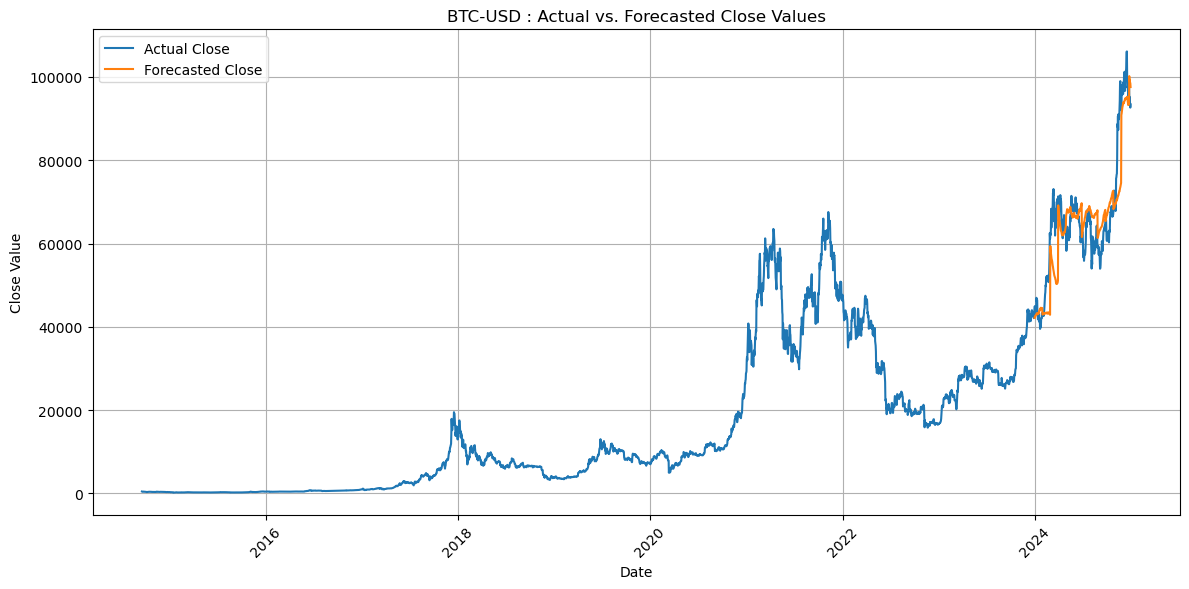

Evaluation Metric for BTC-USD_timesfm_30 Actual Values
MAPE: 8.656919239959219
ME: 1181.6968280396175
MAE: 5763.391329405737
MPE: 0.9923986841218863
RMSE: 7723.288780875668
R: 0.8564529098038081
Scalar Product: 12408091.238891602
Return Score: 0.5095890410958904
Long Return: 0.6210526315789474
Short Return: 0.38857142857142857
Mean Directional Accuracy: 0.5095890410958904
Mean Directional Accuracy Positive: 0.6210526315789474
Mean Directional Accuracy Negative: 0.38857142857142857


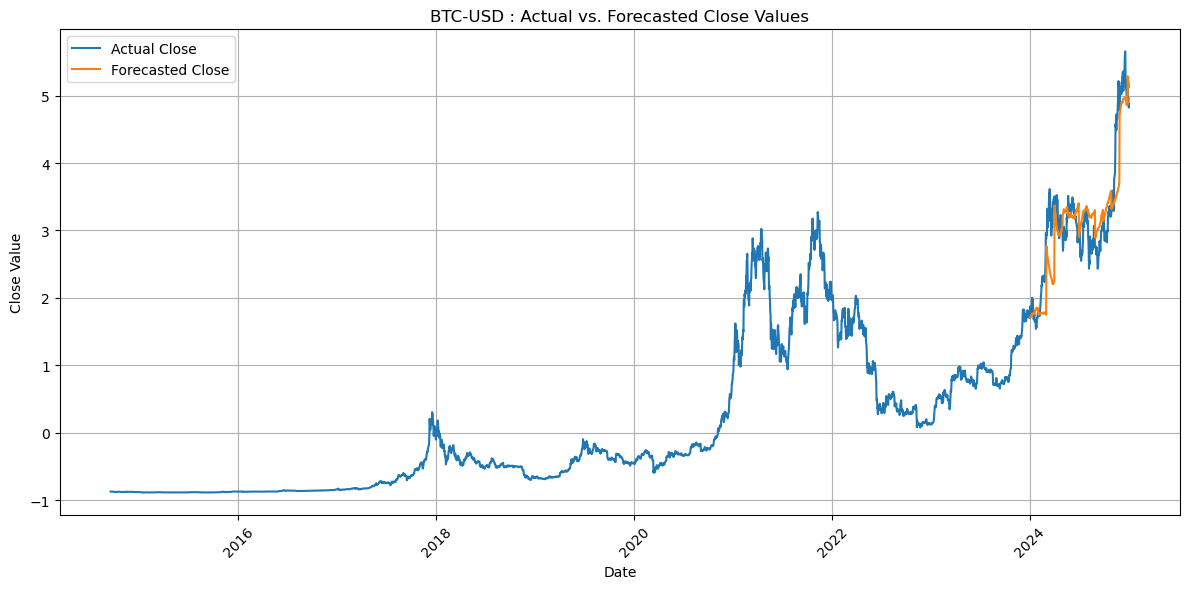

Evaluation Metric for BTC-USD_timesfm_30 Scaled
MAPE: 11.262373117428833
ME: 0.07300403750811434
MAE: 0.3560566408794237
MPE: 1.0410556319396989
RMSE: 0.4771371476097922
R: 0.856452902309581
Scalar Product: 0.04735723918607604
Return Score: 0.5095890410958904
Long Return: 0.6210526315789474
Short Return: 0.38857142857142857
Mean Directional Accuracy: 0.5095890410958904
Mean Directional Accuracy Positive: 0.6210526315789474
Mean Directional Accuracy Negative: 0.38857142857142857
Execution time for forecast_crypto_prices(): 47.82925891876221 seconds


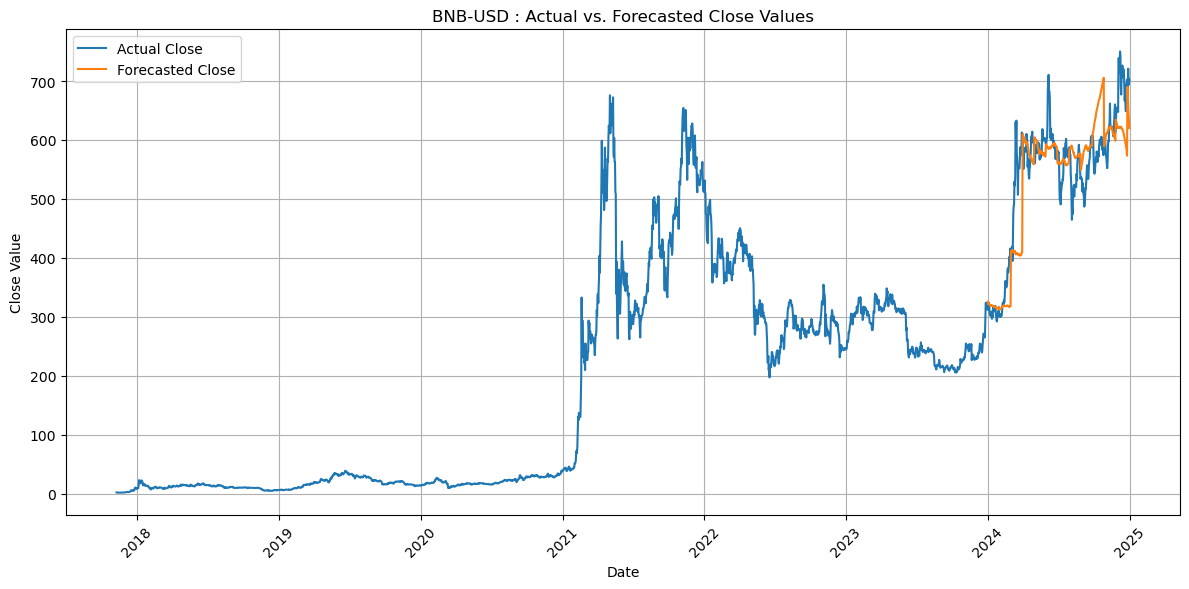

Evaluation Metric for BNB-USD_timesfm_30 Actual Values
MAPE: 8.011538242307779
ME: 7.599390915834187
MAE: 44.54001354780353
MPE: 0.90839242261737
RMSE: 63.01362178686265
R: 0.8439512347892256
Scalar Product: -3356.602309856564
Return Score: 0.4712328767123288
Long Return: 0.4607329842931937
Short Return: 0.4827586206896552
Mean Directional Accuracy: 0.4712328767123288
Mean Directional Accuracy Positive: 0.4607329842931937
Mean Directional Accuracy Negative: 0.4827586206896552


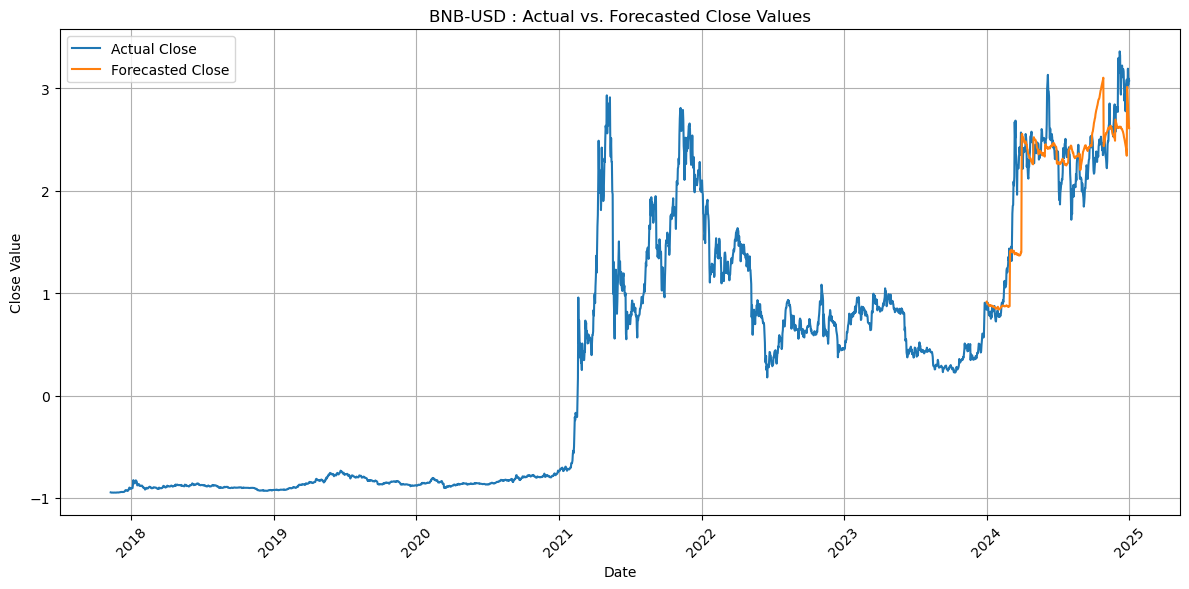

Evaluation Metric for BNB-USD_timesfm_30 Scaled
MAPE: 11.821819906776591
ME: 0.04371229612430174
MAE: 0.2561979058420123
MPE: 0.9978773687756036
RMSE: 0.3624596448264779
R: 0.8439512321395589
Scalar Product: -0.11105814588782728
Return Score: 0.4712328767123288
Long Return: 0.4607329842931937
Short Return: 0.4827586206896552
Mean Directional Accuracy: 0.4712328767123288
Mean Directional Accuracy Positive: 0.4607329842931937
Mean Directional Accuracy Negative: 0.4827586206896552
Execution time for forecast_crypto_prices(): 70.49957013130188 seconds


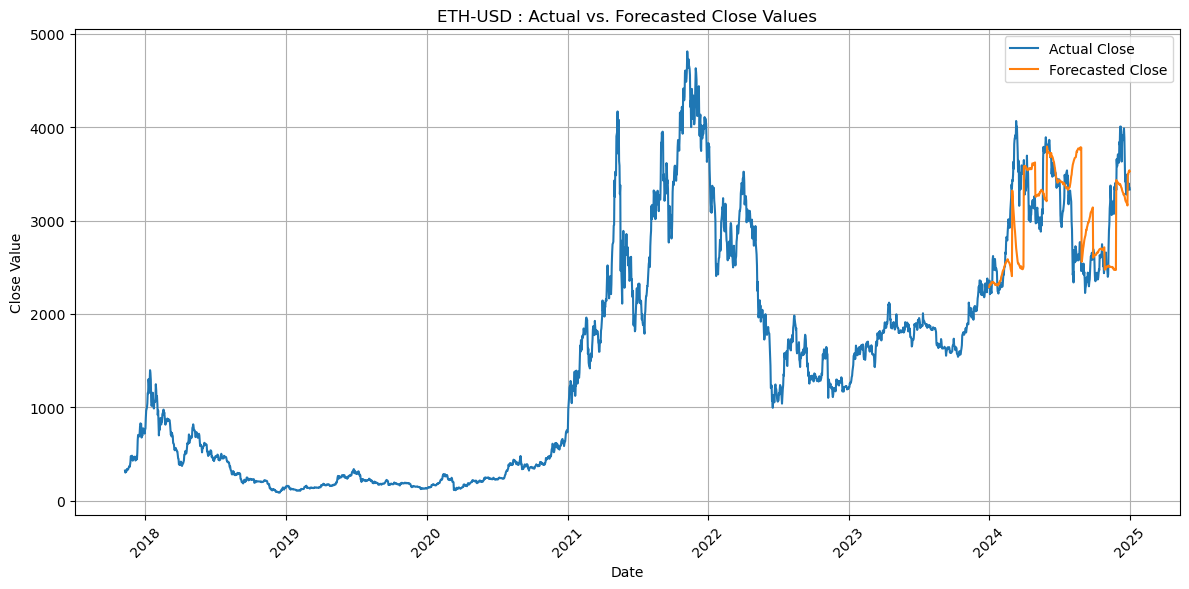

Evaluation Metric for ETH-USD_timesfm_30 Actual Values
MAPE: 12.736040067713539
ME: 1.6134486797728824
MAE: 385.35620050482413
MPE: -1.5180776706069934
RMSE: 517.3716400074741
R: 0.45528896094055343
Scalar Product: -26698.38437455939
Return Score: 0.46301369863013697
Long Return: 0.45549738219895286
Short Return: 0.47126436781609193
Mean Directional Accuracy: 0.46301369863013697
Mean Directional Accuracy Positive: 0.45549738219895286
Mean Directional Accuracy Negative: 0.47126436781609193


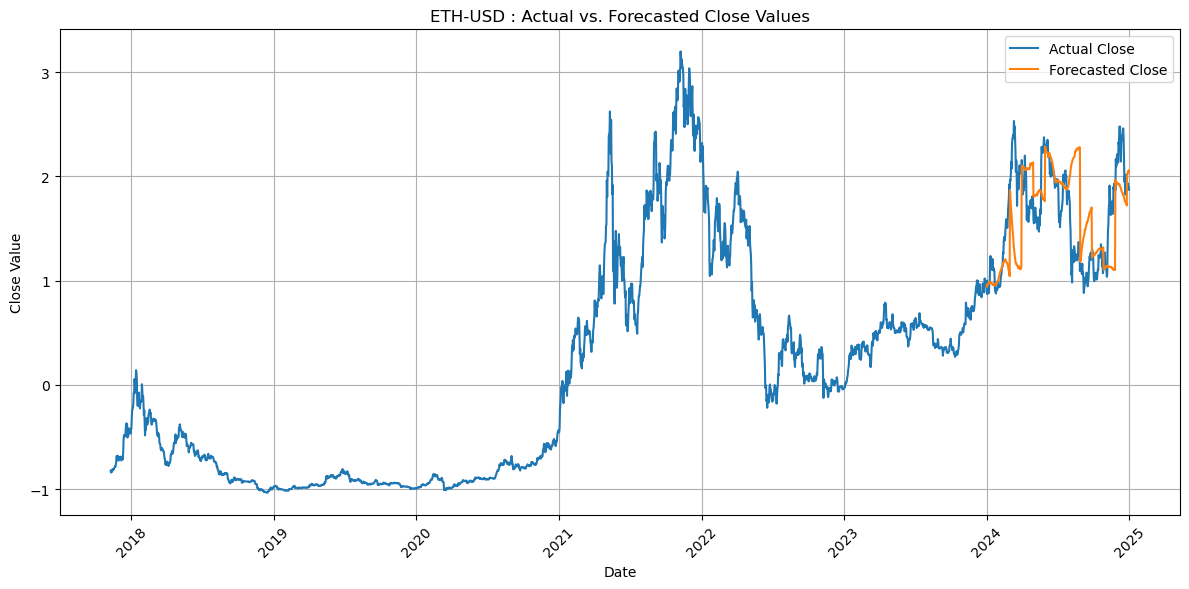

Evaluation Metric for ETH-USD_timesfm_30 Scaled
MAPE: 22.33750626172675
ME: 0.0014436523829000566
MAE: 0.34479825287307575
MPE: -4.591713823625382
RMSE: 0.4629193405720848
R: 0.45528896367298094
Scalar Product: -0.021374246486500936
Return Score: 0.46301369863013697
Long Return: 0.45549738219895286
Short Return: 0.47126436781609193
Mean Directional Accuracy: 0.46301369863013697
Mean Directional Accuracy Positive: 0.45549738219895286
Mean Directional Accuracy Negative: 0.47126436781609193
Execution time for forecast_crypto_prices(): 93.21768689155579 seconds


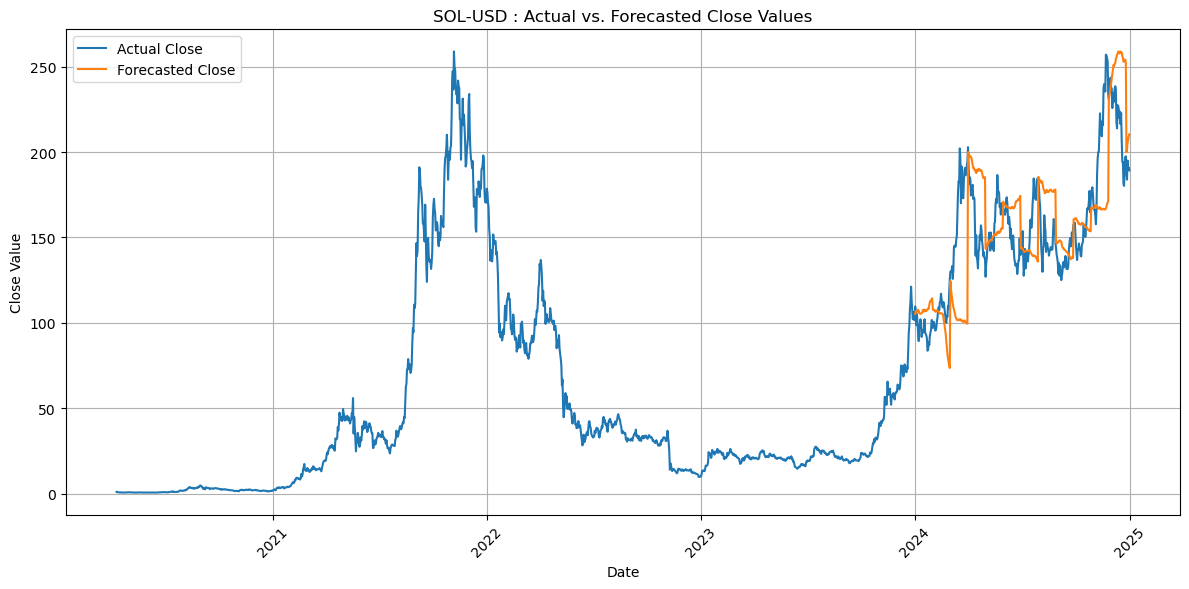

Evaluation Metric for SOL-USD_timesfm_30 Actual Values
MAPE: 14.978101236894107
ME: -0.48022052368831175
MAE: 24.008648398143997
MPE: -1.8105577087378726
RMSE: 32.684025188240746
R: 0.6547067598806426
Scalar Product: 1910.9456788981365
Return Score: 0.4602739726027397
Long Return: 0.4088397790055249
Short Return: 0.5108695652173914
Mean Directional Accuracy: 0.4602739726027397
Mean Directional Accuracy Positive: 0.4088397790055249
Mean Directional Accuracy Negative: 0.5108695652173914


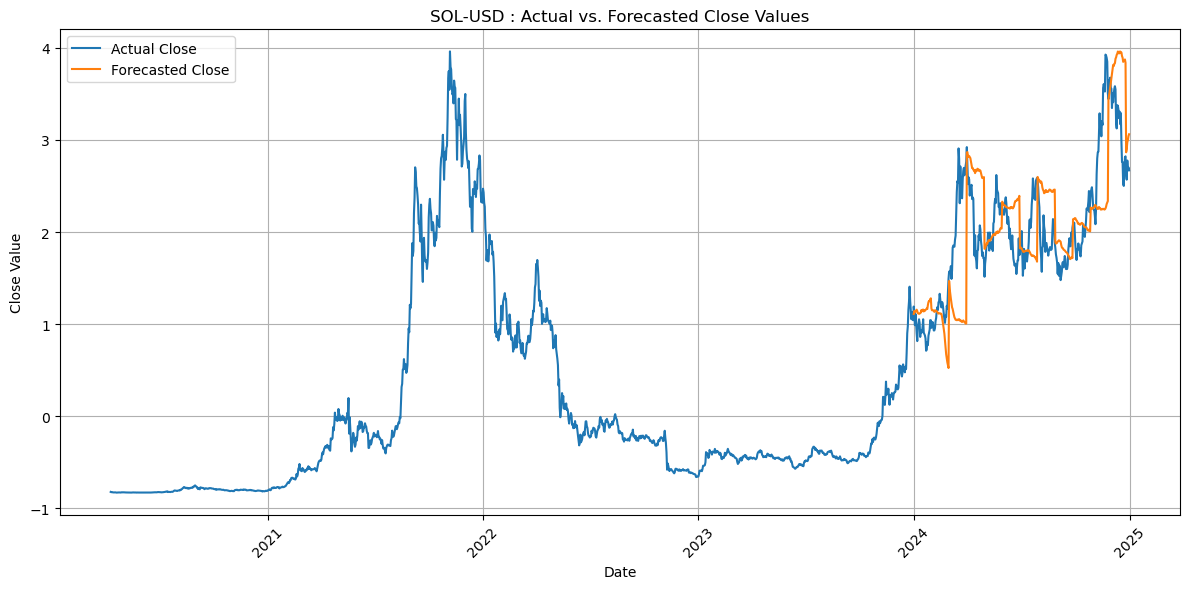

Evaluation Metric for SOL-USD_timesfm_30 Scaled
MAPE: 21.721072055968833
ME: -0.008900059328311713
MAE: 0.4449583249623914
MPE: -3.6463824325571137
RMSE: 0.6057412672087459
R: 0.6547067705234635
Scalar Product: 0.6563741634617606
Return Score: 0.4602739726027397
Long Return: 0.4088397790055249
Short Return: 0.5108695652173914
Mean Directional Accuracy: 0.4602739726027397
Mean Directional Accuracy Positive: 0.4088397790055249
Mean Directional Accuracy Negative: 0.5108695652173914


4402

In [24]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 30, freq='D', scaling = 's')
gc.collect()

9f1b0efa-6688-4e60-8eab-e438972f5c55


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=7, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 87.14314484596252 seconds


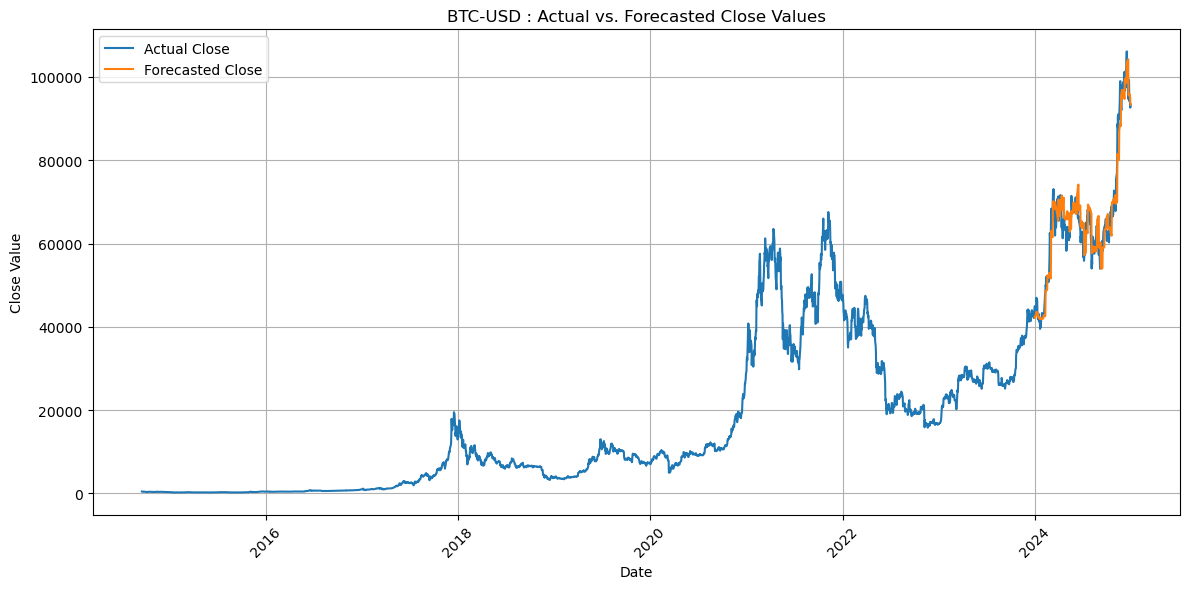

Evaluation Metric for BTC-USD_timesfm_7 Actual Values
MAPE: 5.008997847993746
ME: 75.6209656762295
MAE: 3295.1855575478144
MPE: -0.09387952227880708
RMSE: 4176.522455373584
R: 0.9588782120111031
Scalar Product: 175652370.65419006
Return Score: 0.4986301369863014
Long Return: 0.5421052631578948
Short Return: 0.4514285714285714
Mean Directional Accuracy: 0.4986301369863014
Mean Directional Accuracy Positive: 0.5421052631578948
Mean Directional Accuracy Negative: 0.4514285714285714


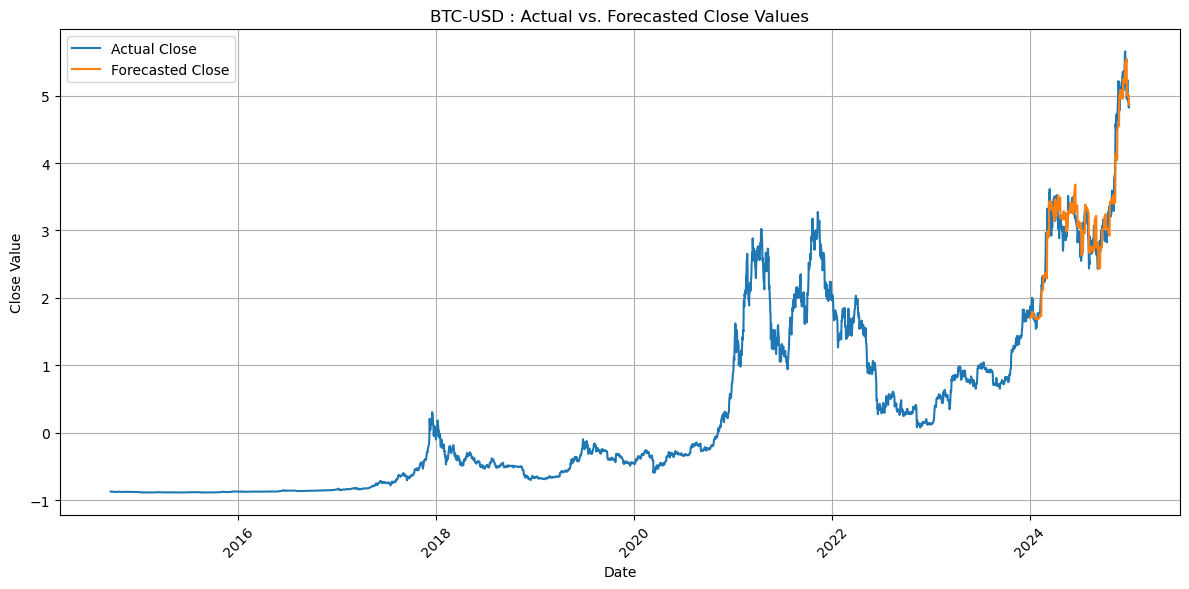

Evaluation Metric for BTC-USD_timesfm_7 Scaled
MAPE: 6.5243596164061435
ME: 0.004671756239103367
MAE: 0.20357331660152164
MPE: -0.1691426177890361
RMSE: 0.25802144200032007
R: 0.9588782060754146
Scalar Product: 0.6704026962749146
Return Score: 0.4986301369863014
Long Return: 0.5421052631578948
Short Return: 0.4514285714285714
Mean Directional Accuracy: 0.4986301369863014
Mean Directional Accuracy Positive: 0.5421052631578948
Mean Directional Accuracy Negative: 0.4514285714285714
Execution time for forecast_crypto_prices(): 171.970383644104 seconds


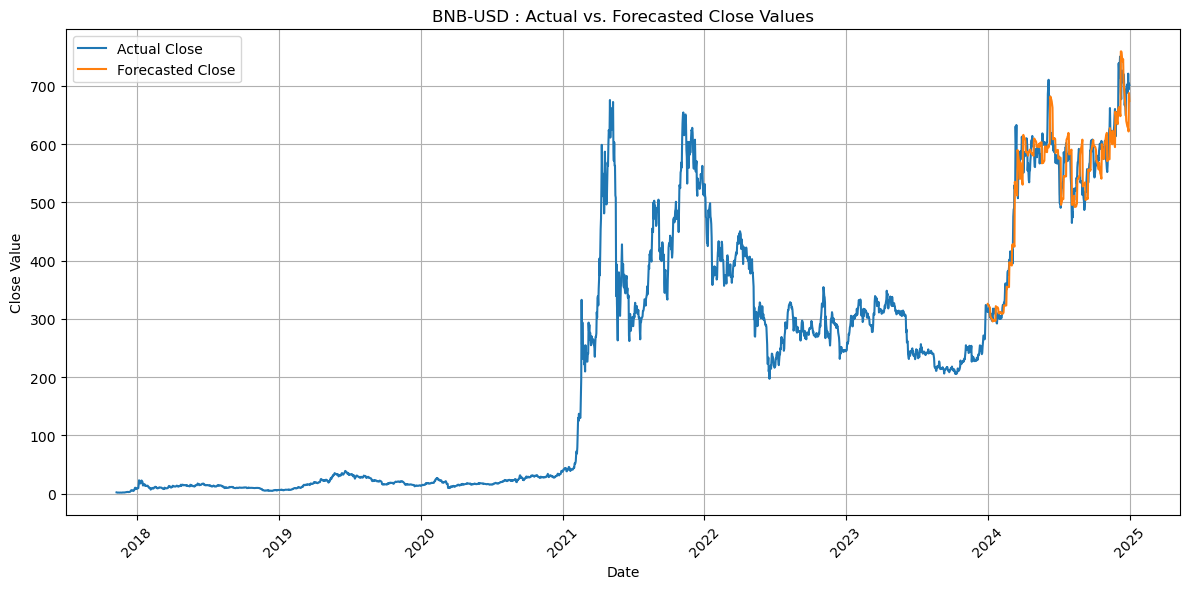

Evaluation Metric for BNB-USD_timesfm_7 Actual Values
MAPE: 5.167181864797632
ME: 3.9352307762604593
MAE: 28.68708851298348
MPE: 0.5244392701576203
RMSE: 37.322850657832205
R: 0.9438995169976868
Scalar Product: -12837.266329252161
Return Score: 0.4794520547945205
Long Return: 0.4293193717277487
Short Return: 0.5344827586206896
Mean Directional Accuracy: 0.4794520547945205
Mean Directional Accuracy Positive: 0.4293193717277487
Mean Directional Accuracy Negative: 0.5344827586206896


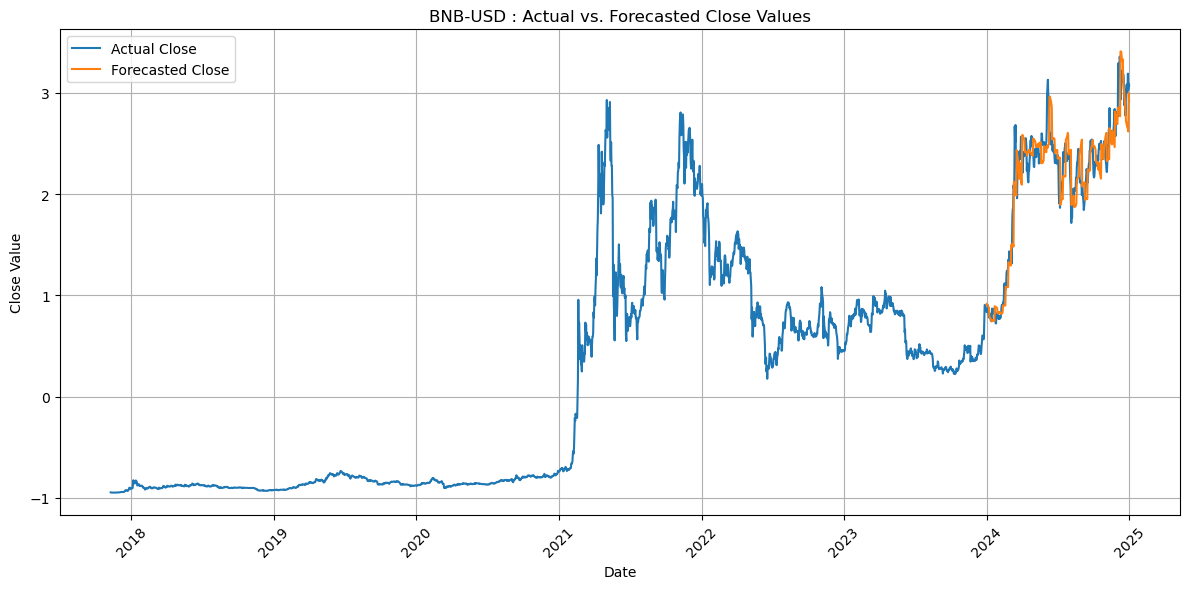

Evaluation Metric for BNB-USD_timesfm_7 Scaled
MAPE: 7.681240352958296
ME: 0.022635735615292307
MAE: 0.165010538803449
MPE: 0.6503668437137751
RMSE: 0.21468416606354349
R: 0.9438995179092124
Scalar Product: -0.4247401576500836
Return Score: 0.4794520547945205
Long Return: 0.4293193717277487
Short Return: 0.5344827586206896
Mean Directional Accuracy: 0.4794520547945205
Mean Directional Accuracy Positive: 0.4293193717277487
Mean Directional Accuracy Negative: 0.5344827586206896
Execution time for forecast_crypto_prices(): 255.83003687858582 seconds


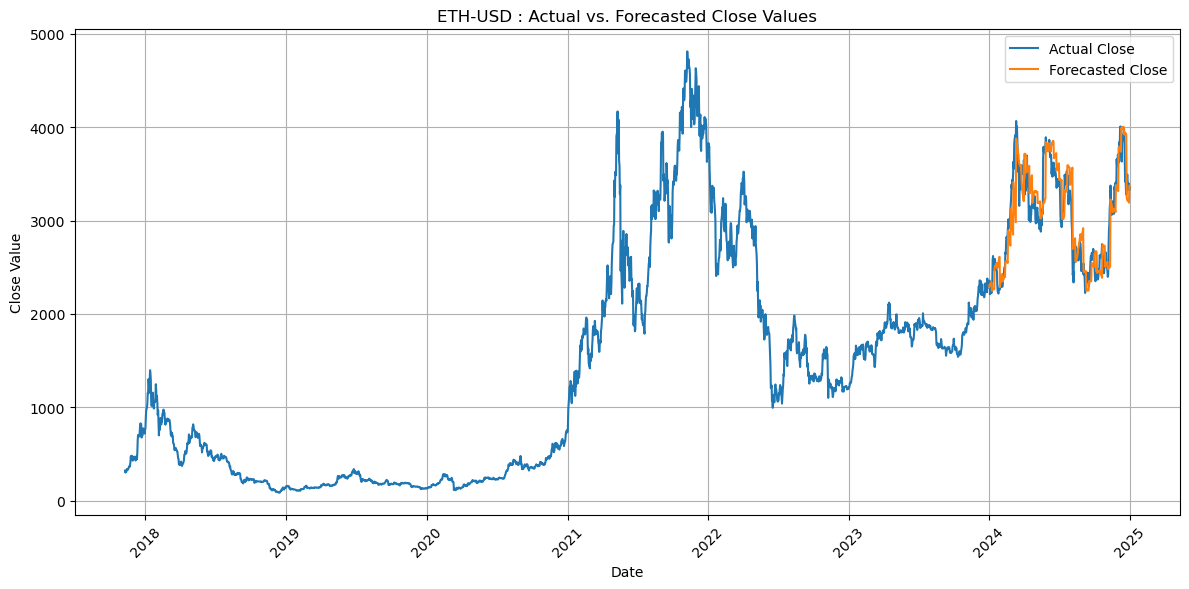

Evaluation Metric for ETH-USD_timesfm_7 Actual Values
MAPE: 6.431701878175867
ME: -17.160978723744883
MAE: 196.34217242464993
MPE: -0.8668130173141769
RMSE: 255.2016498285493
R: 0.8770783188023418
Scalar Product: 354536.9709804063
Return Score: 0.4821917808219178
Long Return: 0.5026178010471204
Short Return: 0.45977011494252873
Mean Directional Accuracy: 0.4821917808219178
Mean Directional Accuracy Positive: 0.5026178010471204
Mean Directional Accuracy Negative: 0.45977011494252873


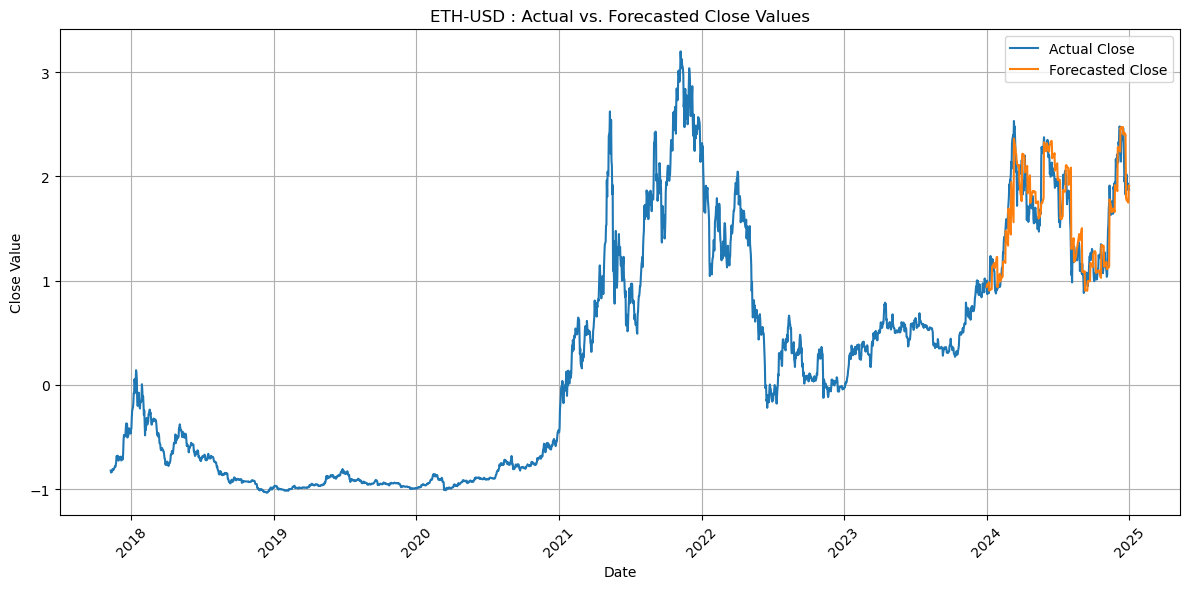

Evaluation Metric for ETH-USD_timesfm_7 Scaled
MAPE: 11.204346788812119
ME: -0.015354807872655075
MAE: 0.17567755732440576
MPE: -1.895238402773845
RMSE: 0.22834219823842528
R: 0.877078322206751
Scalar Product: 0.2838355860673981
Return Score: 0.4821917808219178
Long Return: 0.5026178010471204
Short Return: 0.45977011494252873
Mean Directional Accuracy: 0.4821917808219178
Mean Directional Accuracy Positive: 0.5026178010471204
Mean Directional Accuracy Negative: 0.45977011494252873
Execution time for forecast_crypto_prices(): 339.63222789764404 seconds


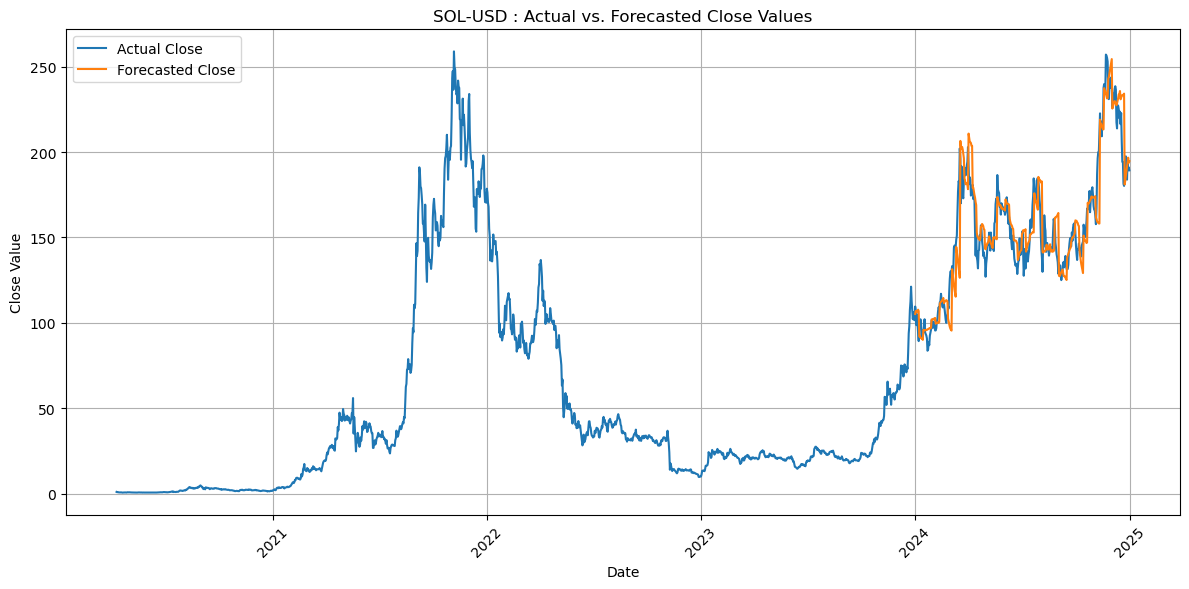

Evaluation Metric for SOL-USD_timesfm_7 Actual Values
MAPE: 6.7310864082492
ME: -0.7168658730762262
MAE: 10.448848369994451
MPE: -0.7974442670282899
RMSE: 15.112573724673897
R: 0.9202497764924021
Scalar Product: 379.2536125964899
Return Score: 0.5315068493150685
Long Return: 0.5359116022099447
Short Return: 0.5271739130434783
Mean Directional Accuracy: 0.5315068493150685
Mean Directional Accuracy Positive: 0.5359116022099447
Mean Directional Accuracy Negative: 0.5271739130434783


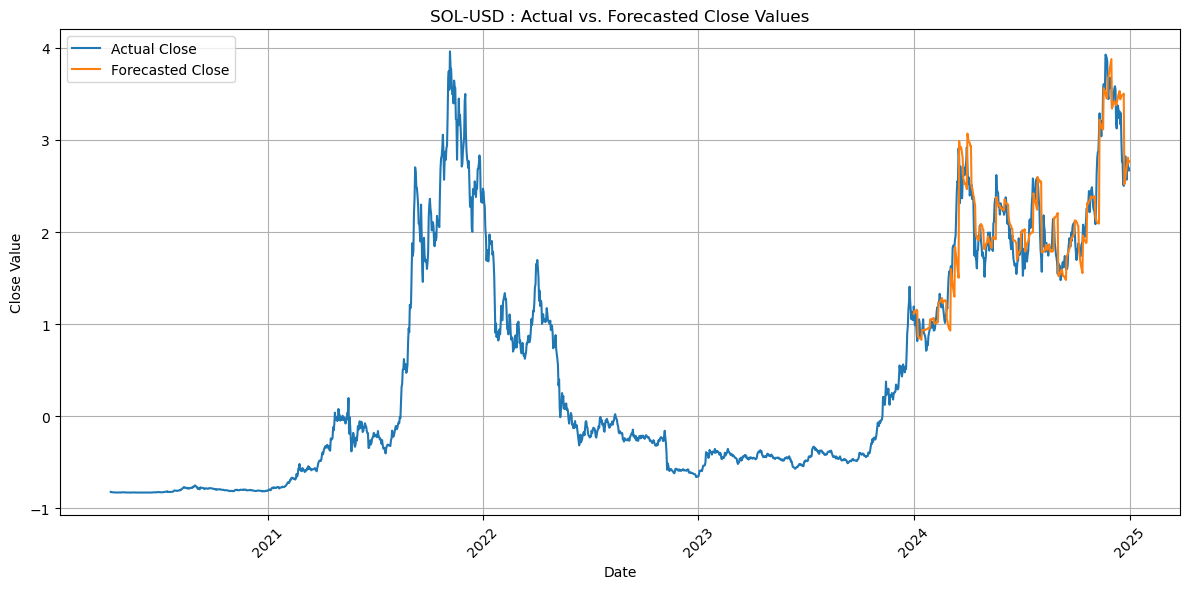

Evaluation Metric for SOL-USD_timesfm_7 Scaled
MAPE: 9.862567020648232
ME: -0.013285877388941719
MAE: 0.19365114139248568
MPE: -1.4290685444634328
RMSE: 0.28008513210236163
R: 0.9202497787693292
Scalar Product: 0.13026638592227197
Return Score: 0.5315068493150685
Long Return: 0.5359116022099447
Short Return: 0.5271739130434783
Mean Directional Accuracy: 0.5315068493150685
Mean Directional Accuracy Positive: 0.5359116022099447
Mean Directional Accuracy Negative: 0.5271739130434783


33765

In [25]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 7, freq='D', scaling = 's')
gc.collect()

0197f219-20ce-4025-8630-dd969ad713e6


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=1, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 568.1691610813141 seconds


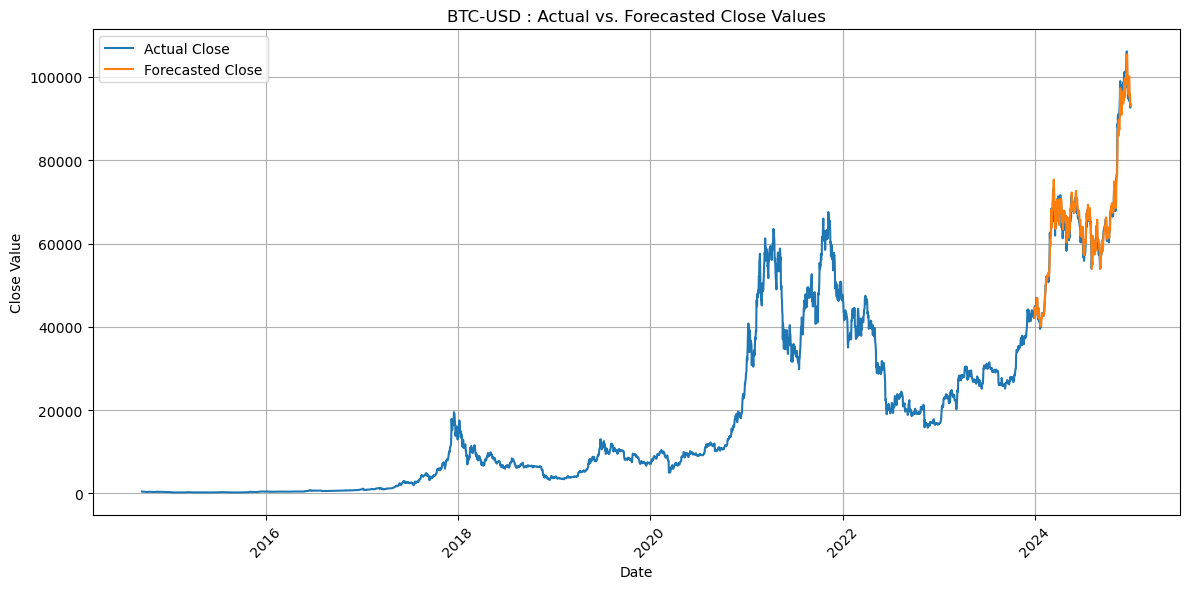

Evaluation Metric for BTC-USD_timesfm_1 Actual Values
MAPE: 2.5363781206404554
ME: -304.99057590505464
MAE: 1688.066566342213
MPE: -0.6222494609471307
RMSE: 2211.5858002691944
R: 0.9889290452074864
Scalar Product: -22486499.88241577
Return Score: 0.4876712328767123
Long Return: 0.5157894736842106
Short Return: 0.45714285714285713
Mean Directional Accuracy: 0.4876712328767123
Mean Directional Accuracy Positive: 0.5157894736842106
Mean Directional Accuracy Negative: 0.45714285714285713


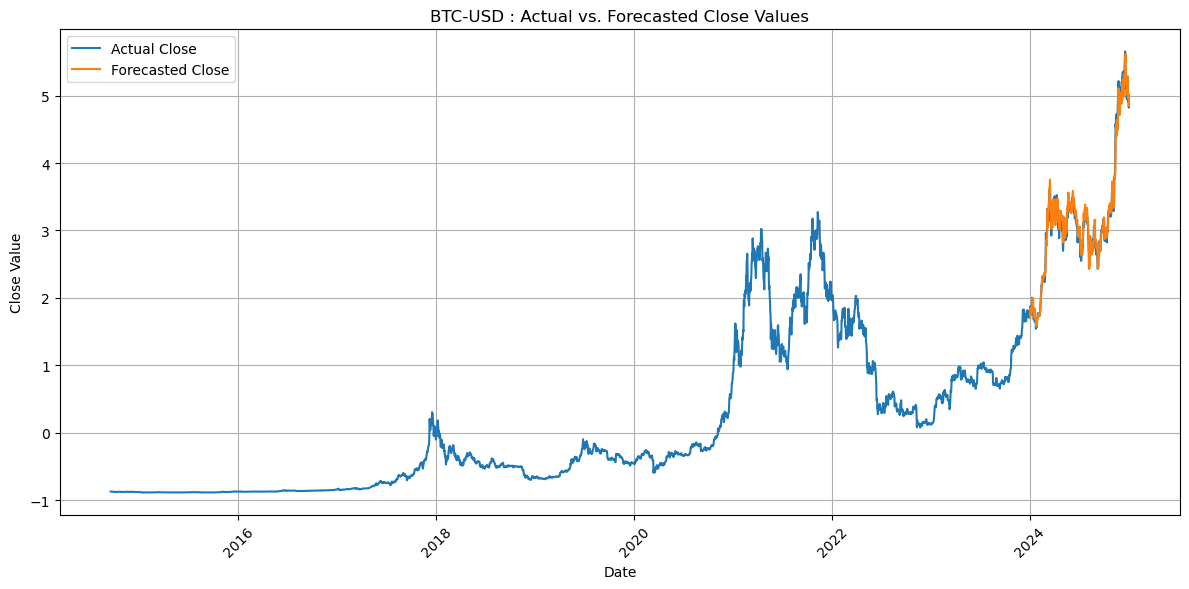

Evaluation Metric for BTC-USD_timesfm_1 Scaled
MAPE: 3.302872231481311
ME: -0.01884205040883834
MAE: 0.10428710291752018
MPE: -0.8535181106749868
RMSE: 0.1366296036086903
R: 0.988929043522617
Scalar Product: -0.085822466029636
Return Score: 0.4876712328767123
Long Return: 0.5157894736842106
Short Return: 0.45714285714285713
Mean Directional Accuracy: 0.4876712328767123
Mean Directional Accuracy Positive: 0.5157894736842106
Mean Directional Accuracy Negative: 0.45714285714285713
Execution time for forecast_crypto_prices(): 1130.2997410297394 seconds


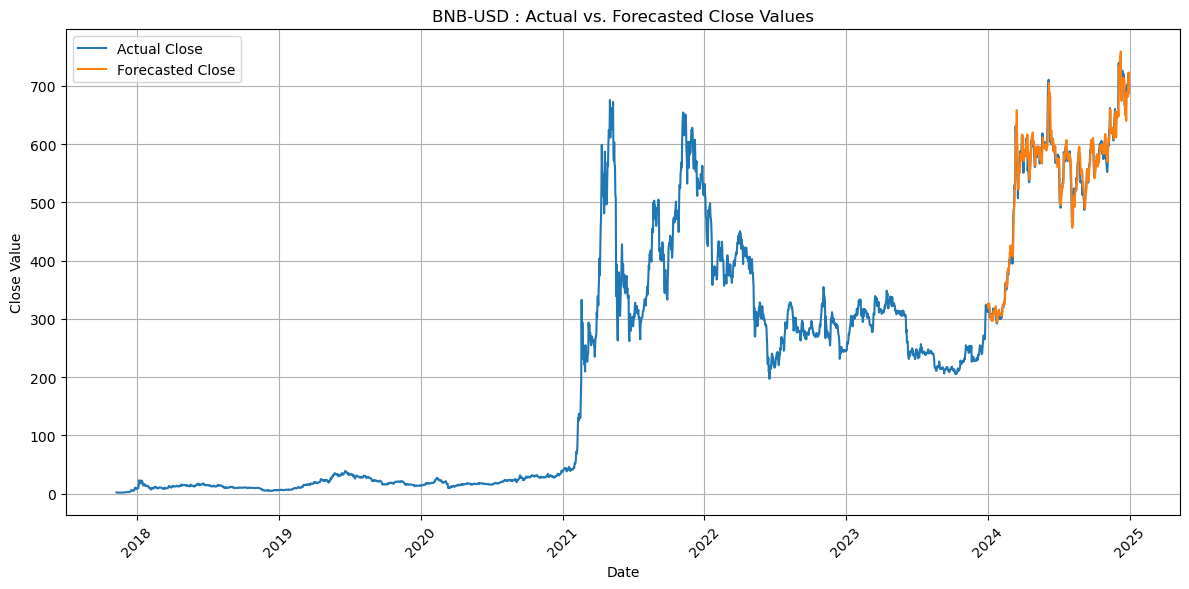

Evaluation Metric for BNB-USD_timesfm_1 Actual Values
MAPE: 2.4017758664042343
ME: -0.8365149159249061
MAE: 13.097283618697704
MPE: -0.2649133621101243
RMSE: 18.70480764413425
R: 0.9857738065613719
Scalar Product: -2818.033070786857
Return Score: 0.4712328767123288
Long Return: 0.5235602094240838
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4712328767123288
Mean Directional Accuracy Positive: 0.5235602094240838
Mean Directional Accuracy Negative: 0.41379310344827586


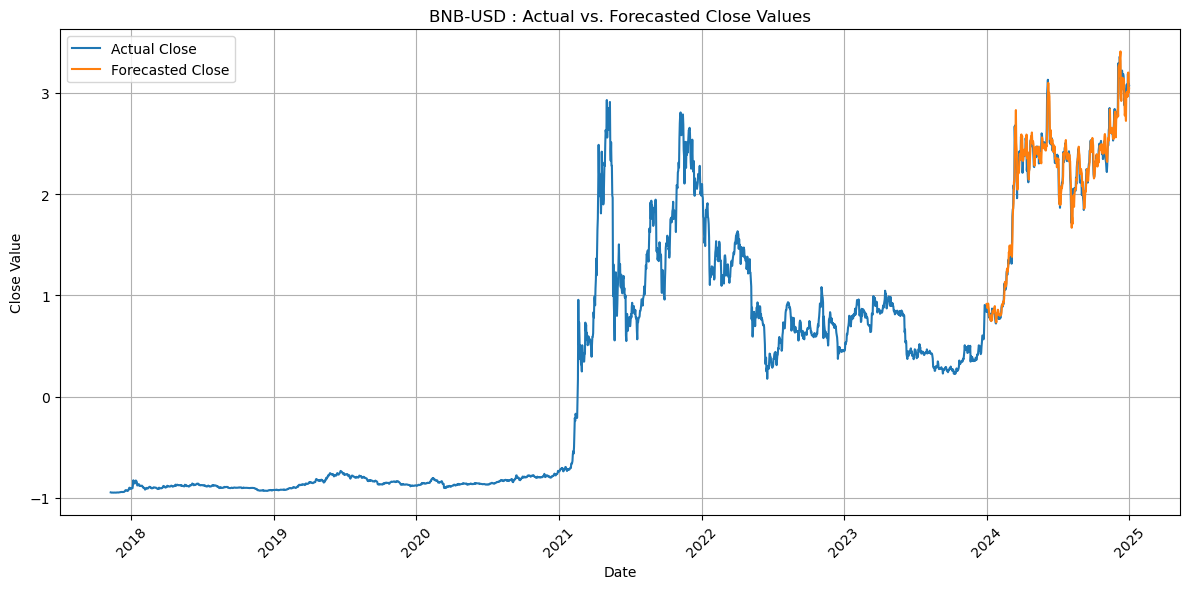

Evaluation Metric for BNB-USD_timesfm_1 Scaled
MAPE: 3.6149689403570684
ME: -0.0048117504061873165
MAE: 0.07533667806403371
MPE: -0.49973997511169
RMSE: 0.1075916317136349
R: 0.9857738053255344
Scalar Product: -0.09323868466422519
Return Score: 0.4712328767123288
Long Return: 0.5235602094240838
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4712328767123288
Mean Directional Accuracy Positive: 0.5235602094240838
Mean Directional Accuracy Negative: 0.41379310344827586
Execution time for forecast_crypto_prices(): 1656.1419262886047 seconds


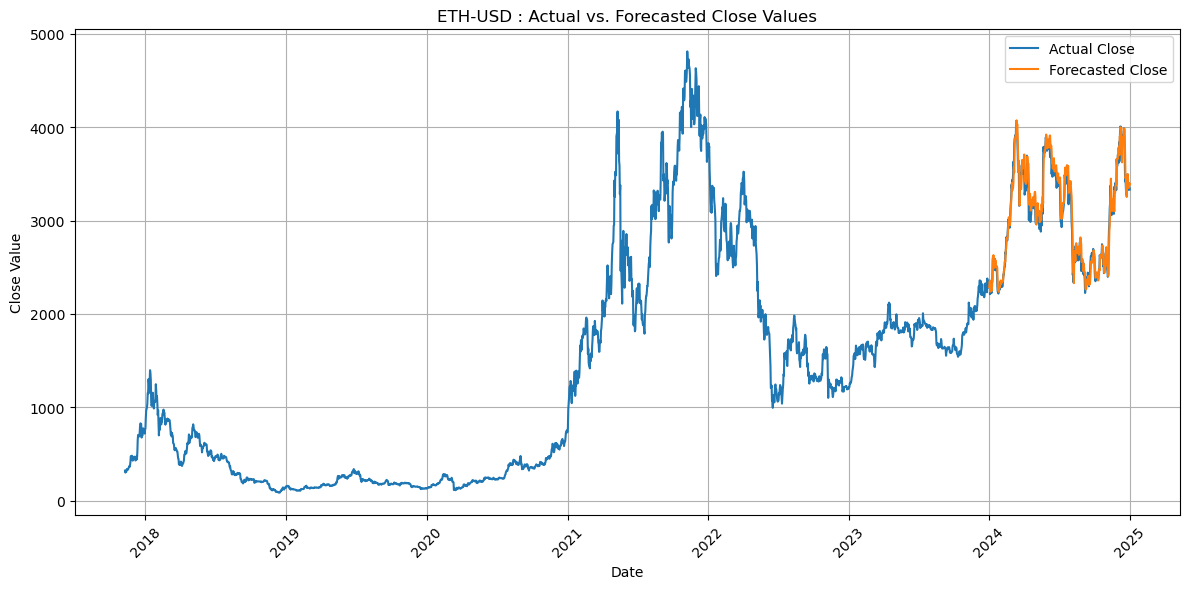

Evaluation Metric for ETH-USD_timesfm_1 Actual Values
MAPE: 2.9200857075252844
ME: -29.457300738558754
MAE: 89.08341337943989
MPE: -0.9997257716976775
RMSE: 118.75794535827154
R: 0.9751251156491161
Scalar Product: -49549.65831541979
Return Score: 0.4547945205479452
Long Return: 0.49214659685863876
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4547945205479452
Mean Directional Accuracy Positive: 0.49214659685863876
Mean Directional Accuracy Negative: 0.41379310344827586


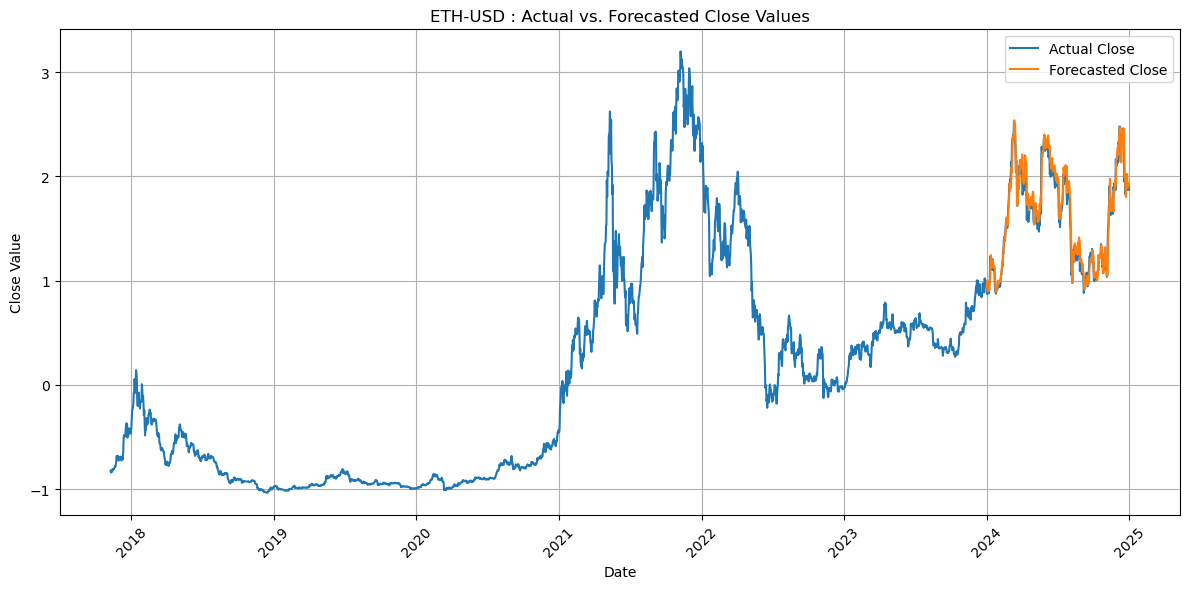

Evaluation Metric for ETH-USD_timesfm_1 Scaled
MAPE: 5.0765651400889
ME: -0.02635696998782508
MAE: 0.07970756941564248
MPE: -1.7706048042811042
RMSE: 0.10625891524024024
R: 0.9751251147988974
Scalar Product: -0.03966862649719542
Return Score: 0.4547945205479452
Long Return: 0.49214659685863876
Short Return: 0.41379310344827586
Mean Directional Accuracy: 0.4547945205479452
Mean Directional Accuracy Positive: 0.49214659685863876
Mean Directional Accuracy Negative: 0.41379310344827586
Execution time for forecast_crypto_prices(): 2177.962978363037 seconds


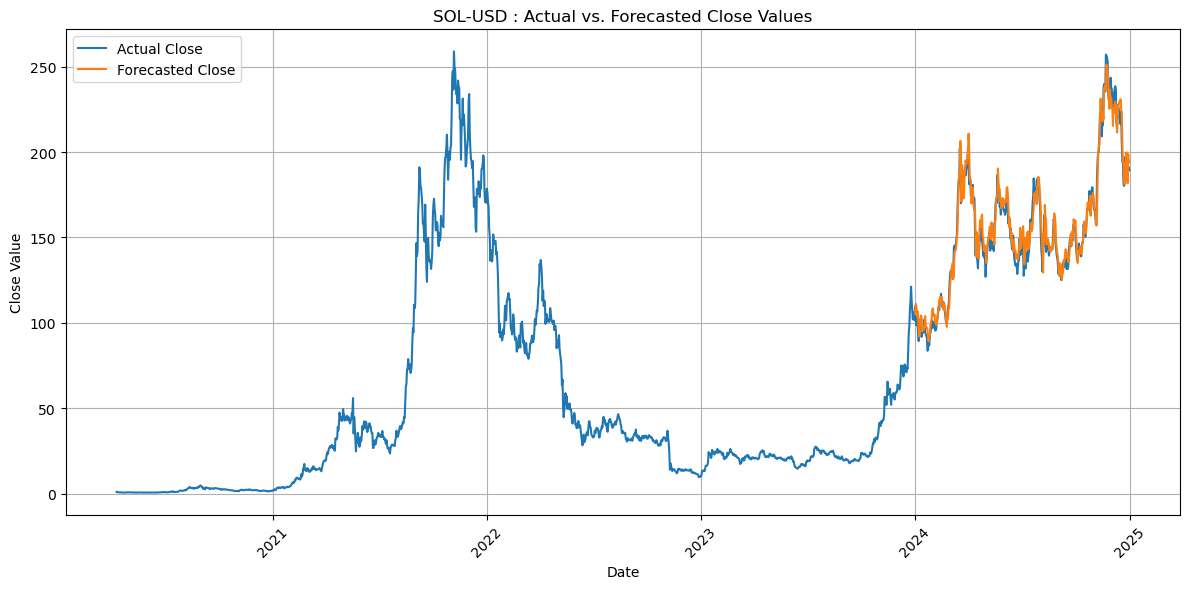

Evaluation Metric for SOL-USD_timesfm_1 Actual Values
MAPE: 3.993976287085198
ME: -1.555406622547922
MAE: 6.099023412485591
MPE: -1.3432114712081684
RMSE: 7.804192760815141
R: 0.9787225395260907
Scalar Product: -981.3089028536318
Return Score: 0.5205479452054794
Long Return: 0.5193370165745856
Short Return: 0.5217391304347826
Mean Directional Accuracy: 0.5205479452054794
Mean Directional Accuracy Positive: 0.5193370165745856
Mean Directional Accuracy Negative: 0.5217391304347826


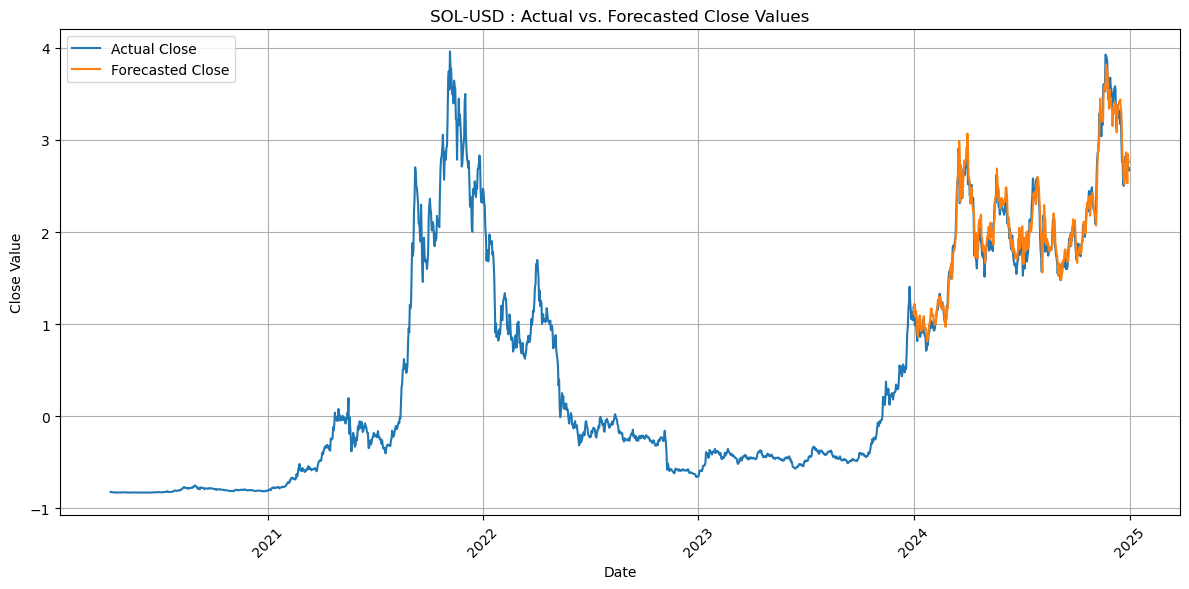

Evaluation Metric for SOL-USD_timesfm_1 Scaled
MAPE: 5.926052360905227
ME: -0.02882675878688736
MAE: 0.11303474941816391
MPE: -2.2189992039536683
RMSE: 0.14463708046220594
R: 0.9787225390835417
Scalar Product: -0.3370610739049979
Return Score: 0.5205479452054794
Long Return: 0.5193370165745856
Short Return: 0.5217391304347826
Mean Directional Accuracy: 0.5205479452054794
Mean Directional Accuracy Positive: 0.5193370165745856
Mean Directional Accuracy Negative: 0.5217391304347826


33482

In [26]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 1, freq='D', scaling = 's')
gc.collect()